In [1]:
from dynrdpg import DynamicRDPG
from dynrdpg.datasets import simulate_network_rw, simulate_network_gp
from dynrdpg.datasets import simulate_network_bspline

0.1944872727272728


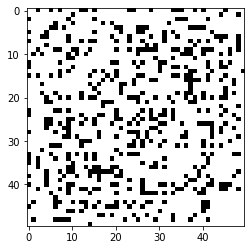

In [125]:
k_steps = 5

Y, X, probas_true = simulate_network_gp(
    n_nodes=50, n_time_steps=50 + k_steps, 
    density=0.2, random_state=32, length_scale=3)

print(np.mean([Yt.mean() for Yt in Y]))

plt.imshow(Y[-1].toarray(), cmap='gray_r')

0.2908370454545448


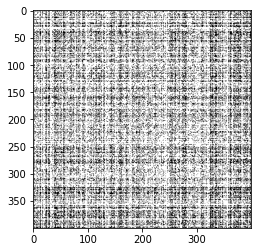

In [71]:
k_steps = 5

Y, X, probas_true = simulate_network_bspline(
    n_nodes=400, n_time_steps=50, k_steps=k_steps,
    density=0.3, random_state=3, df=5)

print(np.mean([Yt.mean() for Yt in Y]))

plt.imshow(Y[-1].toarray(), cmap='gray_r')

In [95]:
import os

out_dir = f'fase_data/'
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

np.savetxt(os.path.join(out_dir, 'time_points.npy'), np.linspace(0, 1, len(Y)))
for t in range(len(Y)):
    np.savetxt(os.path.join(out_dir, f'Y_{t+1}.npy'), Y[t].toarray())
    np.savetxt(os.path.join(out_dir, f'X_{t+1}.npy'), X[t])

In [96]:
! Rscript fase.R

Type 'citation("pROC")' for a citation.

Attaching package: ‘pROC’

The following objects are masked from ‘package:stats’:

    cov, smooth, var


── Column specification ────────────────────────────────────────────────────────
cols(
  X1 = col_double()
)

[1] "q = 4 ngcv = -1.25575300799602"
[1] "q = 6 ngcv = -1.25582763094738"
[1] "q = 8 ngcv = -1.25538607883514"
[1] "q = 10 ngcv = -1.2550044198903"
      fase_mse fase_kstep_0 fase_kstep_1 fase_kstep_2 fase_kstep_3 fase_kstep_4
1 0.0007889966 0.0005572257 0.0007150415 0.0009354053  0.001218828  0.001566294
  fase_kstep_5
1  0.001979266


In [72]:
k_steps = 5

rdpg = DynamicRDPG(n_features=2, rw_order=2)
rdpg.sample(Y[:-k_steps], n_burnin=100, n_samples=100)

100%|███████████████████████████████████████████████████████████████████| 200/200 [02:24<00:00,  1.39it/s]


In [136]:
from scipy.linalg import orthogonal_procrustes

X_pred = rdpg.X_.copy()
for t in range(len(Y)-k_steps):
    R, _ = orthogonal_procrustes(X_pred[t], X[t])
    X_pred[t] = X_pred[t] @ R
    
#print(rdpg.auc_)
np.mean((X_pred - X[:-k_steps]) ** 2)

0.0041243177807232115

In [137]:
rdpg.probas_.shape

(50, 4950)

In [138]:
from sklearn.metrics import roc_auc_score, log_loss

subdiag = np.tril_indices(rdpg.X_.shape[1], k=-1)
y_pred = rdpg.forecast(k_steps=k_steps, return_subdiag=True)#.mean(axis=0)


#print(np.mean((probas_true[-k_steps-1][subdiag] - rdpg.probas_[-1])**2))
#for k in range(k_steps):
#    y_predk = y_pred[k][subdiag]
#    print(np.mean((probas_true[(k-k_steps)][subdiag] - y_predk) ** 2))

In [139]:
cis = np.quantile(y_pred[:, -5], q=[0.025, 0.975], axis=0)

In [140]:
(cis[1] - cis[0]).mean()

0.18050090346070355

In [141]:
np.median(cis[1] - cis[0])

0.17003766706992035

In [142]:
np.logical_and(probas_true[-5][subdiag] <= cis[1], 
               probas_true[-5][subdiag] >= cis[0]).mean() 

0.937979797979798

In [105]:
from sklearn.metrics import classification_report, precision_recall_fscore_support, roc_auc_score

In [106]:
y_hat = y_pred.mean(axis=0)[0] 
y_true = Y[-5].toarray()[subdiag]
print(np.mean((y_hat - y_true) ** 2))
print(roc_auc_score(y_true, y_hat))
print(classification_report(y_true, y_hat > 0.5))

0.12615126336842628
0.7811494818674838
              precision    recall  f1-score   support

         0.0       0.84      0.97      0.90       986
         1.0       0.70      0.26      0.38       239

    accuracy                           0.83      1225
   macro avg       0.77      0.62      0.64      1225
weighted avg       0.82      0.83      0.80      1225



In [107]:
y_hat = y_pred.mean(axis=0)[0] 
y_true = Y[-5].toarray()[subdiag]
print(np.mean((y_hat - y_true) ** 2))
print(roc_auc_score(y_true, y_hat))
print(classification_report(y_true, y_hat > 0.5))

0.12615126336842628
0.7811494818674838
              precision    recall  f1-score   support

         0.0       0.84      0.97      0.90       986
         1.0       0.70      0.26      0.38       239

    accuracy                           0.83      1225
   macro avg       0.77      0.62      0.64      1225
weighted avg       0.82      0.83      0.80      1225



In [73]:
from sklearn.metrics import roc_auc_score, log_loss

subdiag = np.tril_indices(rdpg.X_.shape[1], k=-1)
y_pred = rdpg.forecast(k_steps=k_steps, return_subdiag=True).mean(axis=0)


print(np.mean((probas_true[-k_steps-1][subdiag] - rdpg.probas_[-1])**2))
for k in range(k_steps):
    y_predk = y_pred[k]
    print(np.mean((probas_true[(k-k_steps)][subdiag] - y_predk) ** 2))

0.0020576582148526695
0.0019102711271202716
0.0024142361453174787
0.003055705385158702
0.003806643232318636
0.004624749183056268


In [74]:
from sklearn.metrics import roc_auc_score, log_loss

subdiag = np.tril_indices(rdpg.X_.shape[1], k=-1)
y_pred = rdpg.forecast(k_steps=k_steps, return_subdiag=True).mean(axis=0)


print(np.median(np.abs((probas_true[-k_steps-1][subdiag] - rdpg.probas_[-1]) / 
      probas_true[-k_steps-1][subdiag])))
for k in range(k_steps):
    y_predk = y_pred[k]
    #print(np.mean((probas_true[(k-k_steps)][subdiag] - y_predk) ** 2))
    print(np.median(np.abs((probas_true[(k-k_steps)][subdiag] - y_predk)/
                  probas_true[(k-k_steps)][subdiag])))

0.0968240187524422
0.10722230316309231
0.1249211201324534
0.14577328765142206
0.16933972919419416
0.19342778060822852


In [83]:
from sklearn.metrics import roc_auc_score, log_loss

subdiag = np.tril_indices(rdpg.X_.shape[1], k=-1)
y_pred = rdpg.forecast(k_steps=k_steps, return_subdiag=True).mean(axis=0)


print(np.mean(np.abs((probas_true[-k_steps-1][subdiag] - rdpg.probas_[-1]))
              / probas_true[-k_steps-1][subdiag]))
for k in range(k_steps):
    y_predk = y_pred[k]
    #print(np.mean((probas_true[(k-k_steps)][subdiag] - y_predk) ** 2))
    print(np.mean(np.abs((probas_true[(k-k_steps)][subdiag] - y_predk)/
                  probas_true[(k-k_steps)][subdiag])))

0.16581746679182513
0.3007123287247752
0.40207423204505954
0.5435105578555487
0.7457193492109359
1.0557442578943539


In [81]:
np.sum(probas_true[-k_steps-1][subdiag] == 0)

0

In [75]:
ptrue = probas_true[-6:]
true_diff = np.sign(probas_true[-5][subdiag] - probas_true[-6][subdiag])
est_diff = np.sign(y_pred[0] - rdpg.probas_[-1])
np.mean(true_diff == est_diff)

0.792155388471178

In [44]:
rdpg.probas_[-1]

array([ 0.05881749,  0.31564346,  0.14485818, ...,  0.04687388,
       -0.00118803,  0.1618803 ])

In [40]:
y_pred[0]

array([0.04411643, 0.2884737 , 0.12073573, ..., 0.04834241, 0.00216372,
       0.1344504 ])

In [45]:
probas_true[-5][subdiag]

array([0.04981391, 0.23773412, 0.18060657, ..., 0.05320613, 0.00258499,
       0.17522223])

In [42]:
probas_true[-6][subdiag]

array([0.06069622, 0.27055595, 0.19371489, ..., 0.05404629, 0.00317642,
       0.19872504])

In [ ]:
from sklearn.metrics import roc_auc_score, log_loss

subdiag = np.tril_indices(rdpg.X_.shape[1], k=-1)
y_pred = rdpg.forecast(k_steps=k_steps, return_subdiag=True).mean(axis=0)


print(np.mean((probas_true[-k_steps-1][subdiag] - rdpg.probas_[-1])**2))
for k in range(k_steps):
    y_predk = y_pred[k]
    print(np.mean((probas_true[(k-k_steps)][subdiag] - y_predk) ** 2))

In [39]:
from sklearn.metrics import roc_auc_score, log_loss

subdiag = np.tril_indices(rdpg.X_.shape[1], k=-1)
y_pred = rdpg.forecast(k_steps=k_steps, return_subdiag=True).mean(axis=0)


print(np.mean((probas_true[-k_steps-1][subdiag] - rdpg.probas_[-1])**2))
for k in range(k_steps):
    y_predk = y_pred[k]
    print(np.mean((probas_true[(k-k_steps)][subdiag] - y_predk) ** 2))

0.0007881480580480153
0.0009336969570159773
0.0011541113239596933
0.00144255353559964
0.0018059280031288965
0.002256835287565892
